In [4]:
import pandas as pd

df = pd.read_csv(
    "./dataset/NestHeight_SiteMean_raw-1.csv",
    encoding="gb18030",
    dtype={
        "Building#": "string",
        "ID": "string"
    }
)

print("Shape:", df.shape)
display(df.head())

Shape: (657, 26)


,Building#,Altitude,BuildingHeight,BuildingWidth,NestHeight,SquareArea,AveNoise,temp,prec,win,...,NestD1,AvilNest,AvaNR2,gdpp,NestHeightR,DensityR,AvaNR,light,urban,ID
0,Building 11,47.0,30.0,56.0,15.0,5100.0,32.0,19.52,77.17,2.45,...,0.0,40,1.428571,16.490405,6.45000,0.303571,0.714286,62,0.904988,11640
1,Building 3,47.0,27.0,67.0,16.5,1600.0,35.0,19.52,77.17,2.45,...,0.5,48,1.611940,16.490405,4.31235,0.194030,0.716418,62,0.904988,11640
2,Building 8-1,47.0,30.0,56.0,12.0,1600.0,44.0,19.52,77.17,2.45,...,1.0,24,1.428571,16.490405,4.87500,0.178571,0.428571,62,0.904988,11640
3,Building 8-2,47.0,30.0,56.0,19.2,1600.0,47.0,19.52,77.17,2.45,...,0.0,40,1.428571,16.490405,5.32500,0.232143,0.714286,62,0.904988,11640
4,Building 9-1,47.0,30.0,56.0,16.5,1200.0,34.0,19.52,77.17,2.45,...,1.0,32,1.285714,16.490405,4.87500,0.160714,0.571429,62,0.904988,11640


In [7]:
# Checking Structures, and missing value
df.info()

display(df.isna().sum())

print("Exact duplicates:", df.duplicated().sum())
print("Unique building names:", df['Building#'].unique())

display(df['NestCount'].describe())

<class 'pandas.DataFrame'>
RangeIndex: 657 entries, 0 to 656
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Building#       657 non-null    string 
 1   Altitude        657 non-null    float64
 2   BuildingHeight  657 non-null    float64
 3   BuildingWidth   657 non-null    float64
 4   NestHeight      657 non-null    float64
 5   SquareArea      657 non-null    float64
 6   AveNoise        657 non-null    float64
 7   temp            657 non-null    float64
 8   prec            657 non-null    float64
 9   win             657 non-null    float64
 10  nd              657 non-null    float64
 11  npp             657 non-null    float64
 12  pop             657 non-null    float64
 13  lon             657 non-null    float64
 14  lat             657 non-null    float64
 15  NestCount       657 non-null    int64  
 16  NestD1          657 non-null    float64
 17  AvilNest        657 non-null    int64  
 18  A

Building#         0
Altitude          0
BuildingHeight    0
BuildingWidth     0
NestHeight        0
SquareArea        0
AveNoise          0
temp              0
prec              0
win               0
nd                0
npp               0
pop               0
lon               0
lat               0
NestCount         0
NestD1            0
AvilNest          0
AvaNR2            0
gdpp              0
NestHeightR       0
DensityR          0
AvaNR             0
light             0
urban             0
ID                0
dtype: int64

Exact duplicates: 0
Unique building names: <StringArray>
[                        'Building 11',                          'Building 3',
                        'Building 8-1',                        'Building 8-2',
                        'Building 9-1',                        'Building 9-2',
                                'SOHO',       'Aerding Community Building 25',
       'Aerding Community Building 26',       'Aerding Community Building 29',
 ...
                      'Zhonghe Yinjie', 'Zhonghua Jiayuan Phase I Building 4',
       'Zhonghua Jiayuan Phase I No.9',                    'Zhongjing Garden',
                        'Central Park',                     'Zhongyang Meiyu',
          'Zhongyi Jiayuan Building 6',                'Ziruiyuan Building 2',
              'Zuobiaocheng Area D 12',               'Zuobiaocheng Area D 8']
Length: 654, dtype: string


count    657.000000
mean       5.742770
std        5.387645
min        1.000000
25%        2.000000
50%        4.000000
75%        7.000000
max       50.000000
Name: NestCount, dtype: float64

In [ ]:
# Check target class for making prediction task decision on what
print("Zero-nest records", (df['NestCount'] == 0).sum())

display(
    df['NestCount']
    .value_counts()
    .sort_index()
)

Zero-nest records 0


NestCount
1      88
2      82
3     102
4      72
5      59
6      52
7      47
8      38
9      29
10     11
11      9
12     12
13     12
14      3
15      4
16      7
17      6
18      3
19      4
20      3
21      2
22      1
23      2
24      2
25      1
30      2
34      1
38      1
46      1
50      1
Name: count, dtype: int64

In [10]:
# Calculated values
import numpy as np

audit = df.copy()

audit["occupied_density_calc"] = (
    audit["NestCount"] / audit["BuildingWidth"]
)

audit["available_density_calc"] = (
    audit["AvilNest"] / audit["BuildingWidth"]
)

audit["occupied_density_mismatch"] = ~np.isclose(
    audit["DensityR"],
    audit["occupied_density_calc"],
    rtol=1e-6,
    atol=1e-8
)

audit["available_density_mismatch"] = ~np.isclose(
    audit["AvaNR"],
    audit["available_density_calc"],
    rtol=1e-6,
    atol=1e-8
)

display(
    audit.loc[
        audit["occupied_density_mismatch"]
        | audit["available_density_mismatch"],
        [
            "Building#",
            "BuildingWidth",
            "NestCount",
            "AvilNest",
            "DensityR",
            "occupied_density_calc",
            "AvaNR",
            "available_density_calc"
        ]
    ]
)

,Building#,BuildingWidth,NestCount,AvilNest,DensityR,occupied_density_calc,AvaNR,available_density_calc
656,Zuobiaocheng Area D 8,100.0,8,24,0.24,0.08,379.2362,0.24


In [11]:
# Choosing the menaingful columns 
features = [
    "BuildingHeight",
    "BuildingWidth",
    "Altitude",
    "AveNoise",
    "temp",
    "prec",
    "win"
]

target = "NestCount"

display(df[features + [target]].head())

,BuildingHeight,BuildingWidth,Altitude,AveNoise,temp,prec,win,NestCount
0,30.0,56.0,47.0,32.0,19.52,77.17,2.45,17
1,27.0,67.0,47.0,35.0,19.52,77.17,2.45,13
2,30.0,56.0,47.0,44.0,19.52,77.17,2.45,10
3,30.0,56.0,47.0,47.0,19.52,77.17,2.45,13
4,30.0,56.0,47.0,34.0,19.52,77.17,2.45,9


In [13]:
# Checking data types and valid values
work = df.copy() # copying the dataset

for column in features + [target]:
    work[column] = pd.to_numeric(
        work[column],
        errors="coerce"
    )

numeric_values = work[features + [target]]

checks = pd.DataFrame(index=work.index)
checks['missing_or_non_numeric'] = (
    numeric_values.isna().any(axis=1)
)

checks["infinite_value"] = (
    np.isinf(numeric_values).any(axis=1)
)

checks["invalid_building_dimensions"] = (
    (work["BuildingHeight"] <= 0)
    | (work["BuildingWidth"] <= 0)
)

checks["invalid_nest_count"] = (
    (work["NestCount"] < 0)
    | (work["NestCount"] % 1 != 0)
)

checks["negative_rain_or_wind"] = (
    (work["prec"] < 0)
    | (work["win"] < 0)
)

display(checks.sum().rename("FlaggedRows"))

missing_or_non_numeric         0
infinite_value                 0
invalid_building_dimensions    0
invalid_nest_count             0
negative_rain_or_wind          0
Name: FlaggedRows, dtype: int64

In [14]:
# Analysis copying and creating cleaning log
flagged = checks.any(axis=1)

# records only for review
review_rows = work.loc[flagged].copy()

# valid records
clean = work.loc[~flagged].copy()

cleaning_log = pd.DataFrame([
    {
        "Step": "Original data",
        "Rows": len(df)
    },
    {
        "Step": "Flagged for review",
        "Rows": len(review_rows)
    },
    {
        "Step": "Retained for analysis",
        "Rows": len(clean)
    }
])

display(cleaning_log)

,Step,Rows
0,Original data,657
1,Flagged for review,0
2,Retained for analysis,657


In [15]:
# Descriptive statistics

summary = (
    clean[features + [target]]
    .describe()
    .T
)

display(summary.round(2))

,count,mean,std,min,25%,50%,75%,max
BuildingHeight,657.0,31.68,22.52,9.00,18.00,21.00,36.00,110.00
BuildingWidth,657.0,52.63,23.05,6.00,40.00,50.00,67.00,151.00
Altitude,657.0,874.30,535.81,-12.00,670.00,1028.00,1179.73,2328.00
AveNoise,657.0,51.54,8.35,20.00,47.00,52.00,56.00,85.00
temp,657.0,16.64,1.84,12.15,15.07,16.35,17.47,20.48
prec,657.0,52.41,17.89,24.17,37.33,55.83,64.33,89.67
win,657.0,2.60,0.47,1.68,2.43,2.52,2.80,4.15
NestCount,657.0,5.74,5.39,1.00,2.00,4.00,7.00,50.00


In [16]:
# Import for distribution charts
%pip install matplotlib seaborn scikit-learn

  Using cached matplotlib-3.11.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.9.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.3.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached matplotlib-3.11.1-cp313-cp313-macosx_11_0_arm64.whl (9.3 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached scikit_learn-1.9.0-cp313-cp313-macosx_12_0_arm64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 7.7 MB/s  0:00:00 et

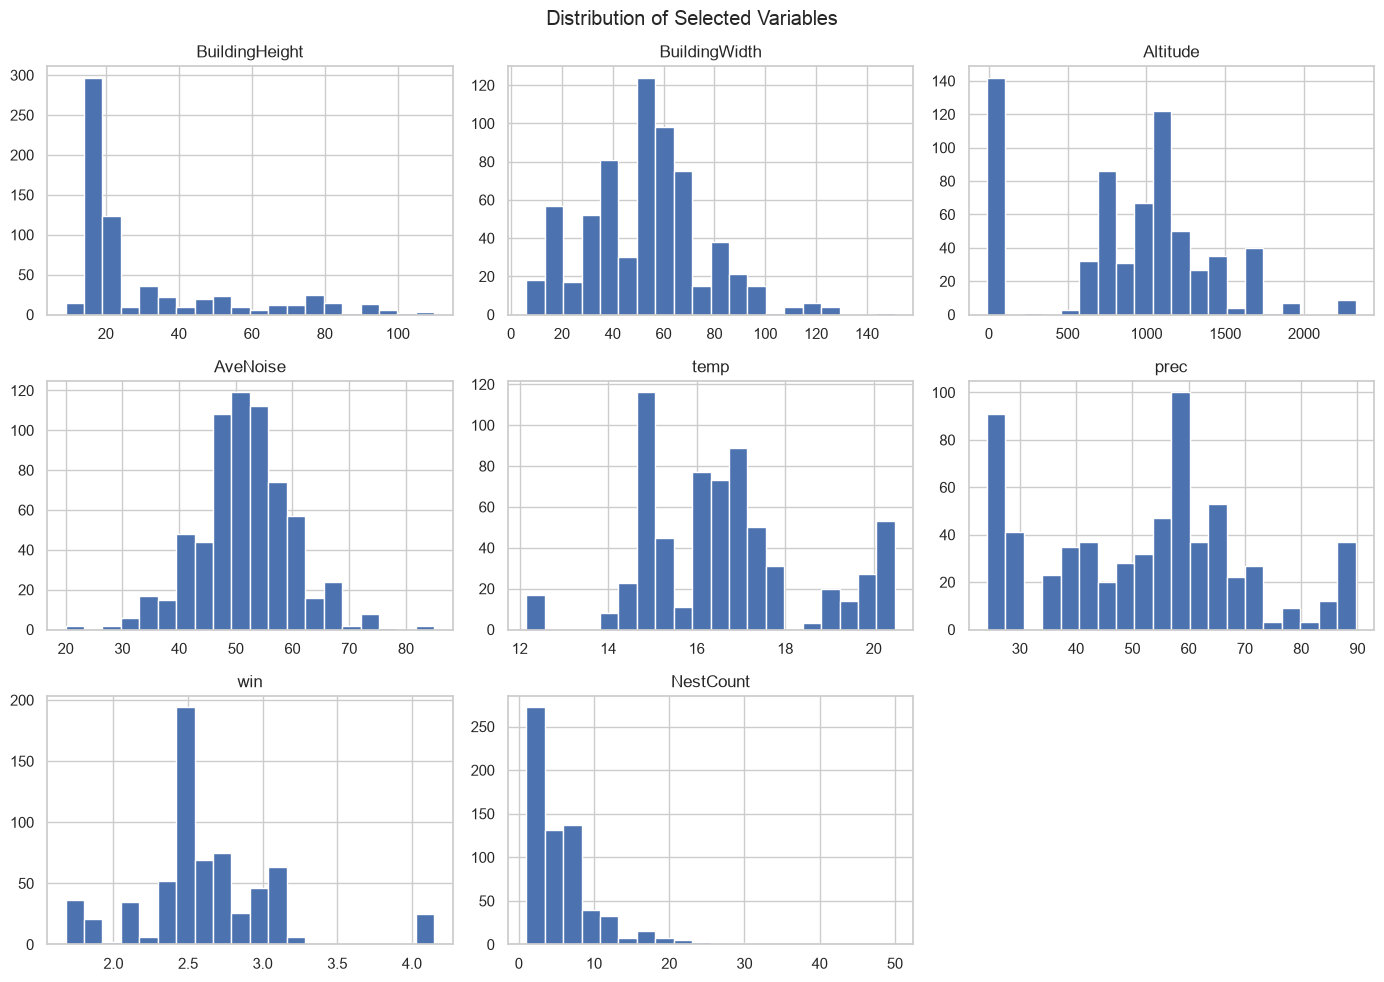

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

clean[features + [target]].hist(
    figsize=(14, 10),
    bins=20,
    edgecolor="white"
)

plt.suptitle("Distribution of Selected Variables")
plt.tight_layout()
plt.show()

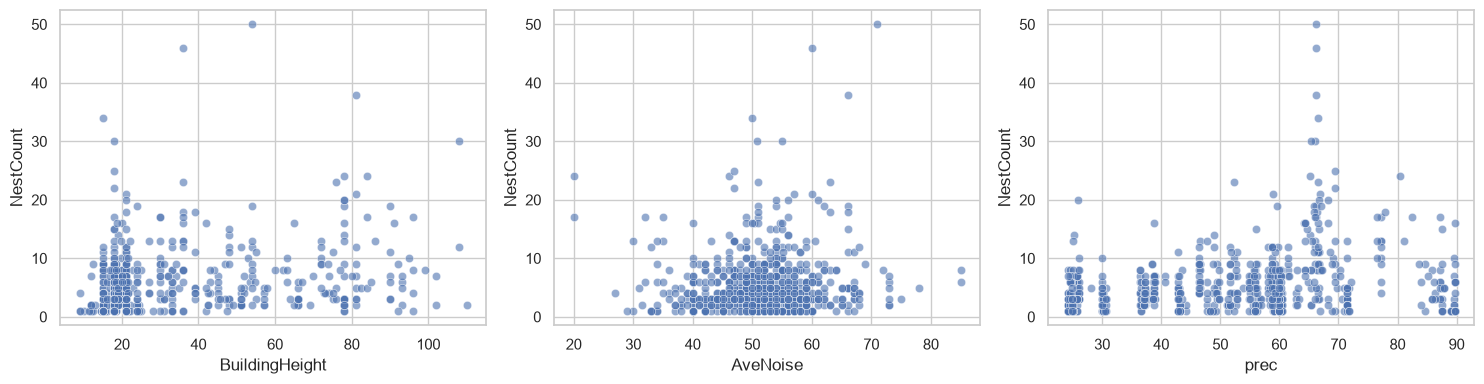

In [18]:
# Checking features and nest count relationship
fig, axes = plt.subplots(
    1, 3,
    figsize=(15,4)
)

for ax, column in zip(
    axes,
    ["BuildingHeight", "AveNoise", "prec"]
):
    sns.scatterplot(
        data=clean,
        x=column,
        y="NestCount",
        alpha=0.6,
        ax=ax
    )

plt.tight_layout()
plt.show()

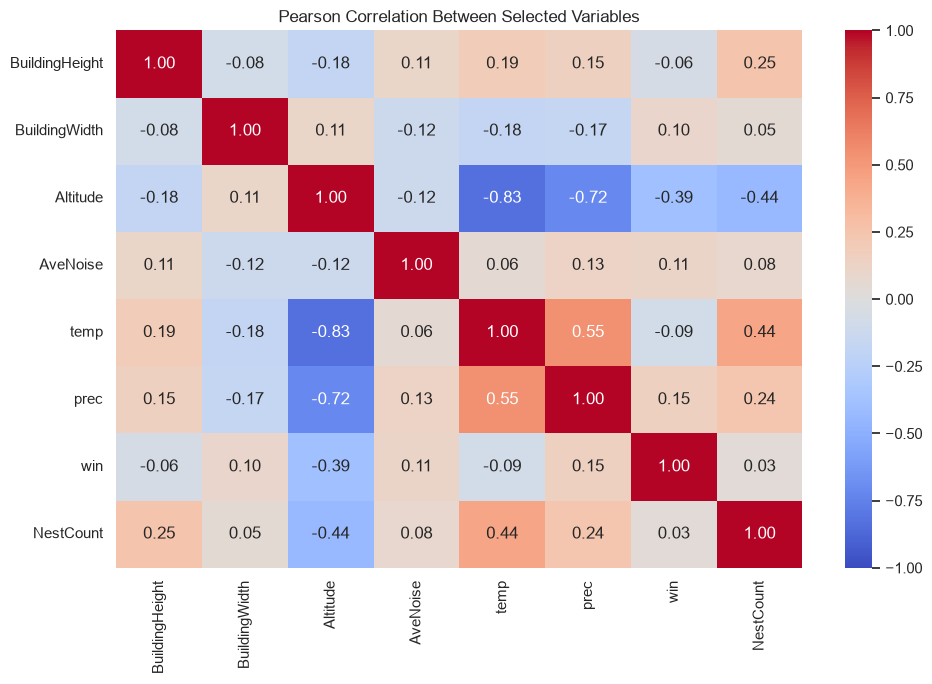

In [19]:
# Correlation table
correlations = clean[
    features + [target]
].corr(method="pearson")

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Pearson Correlation Between Selected Variables")
plt.tight_layout()
plt.show()

In [20]:
# Predicted target
X = clean[features].copy()
y_regression = clean["NestCount"].copy()

In [21]:
COUNT_CUTOFF = 4

clean["HigherNestCount"] = (
    clean["NestCount"] > COUNT_CUTOFF
).astype(int)

y_classification = clean["HigherNestCount"].copy()

display(
    y_classification
    .value_counts()
    .rename(index={
        0: "Lower count: 1–4",
        1: "Higher count: 5 or more"
    })
)

HigherNestCount
Lower count: 1–4           344
Higher count: 5 or more    313
Name: count, dtype: int64

In [22]:
# split train/test
from sklearn.model_selection import GroupShuffleSplit

groups = clean["ID"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        X,
        y_classification,
        groups=groups
    )
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train_cls = y_classification.iloc[train_idx]
y_test_cls = y_classification.iloc[test_idx]

y_train_reg = y_regression.iloc[train_idx]
y_test_reg = y_regression.iloc[test_idx]

train_groups = groups.iloc[train_idx]
test_groups = groups.iloc[test_idx]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print(
    "Overlapping groups:",
    len(set(train_groups) & set(test_groups))
)

print("Training class counts:")
print(y_train_cls.value_counts())

print("Testing class counts:")
print(y_test_cls.value_counts())

Training rows: 501
Testing rows: 156
Overlapping groups: 0
Training class counts:
HigherNestCount
0    276
1    225
Name: count, dtype: int64
Testing class counts:
HigherNestCount
1    88
0    68
Name: count, dtype: int64


In [23]:
# save the result
from pathlib import Path

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

cleaning_log.to_csv(
    output_dir / "cleaning_log.csv",
    index=False
)

summary.to_csv(
    output_dir / "descriptive_statistics.csv",
    index_label="Feature"
)

# Row ကိုမူရင်းဖိုင်နဲ့ပြန်ချိတ်နိုင်ဖို့ source index ထည့်မယ်
model_data = clean[
    ["Building#", "ID"] + features
    + ["NestCount", "HigherNestCount"]
].copy()

model_data.insert(
    0,
    "SourceRowIndex",
    clean.index
)

model_data["Split"] = "train"
model_data.loc[
    X_test.index,
    "Split"
] = "test"

model_data.to_csv(
    output_dir / "sparrow_model_data.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Outputs saved.")

Outputs saved.
